# ⚙️ Feature Engineering — Customer Churn

**Goal:** Transform raw data into model-ready features.

### Sections
1. Setup & Load Data
2. Clean Data
3. Feature Engineering (New Features)
4. Encode Categorical Variables
5. Handle Class Imbalance (SMOTE)
6. Build sklearn Pipeline
7. Save Processed Data

---
## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os, sys

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
TARGET = 'Churn'
print('Libraries loaded ✅')

Libraries loaded ✅


In [2]:
DATA_PATH = '../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


---
## 2. Clean Data

In [3]:
# Drop customerID
df.drop(columns=['customerID'], inplace=True)

# Fix TotalCharges: spaces → NaN → fill with median
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
median_tc = df['TotalCharges'].median()
df['TotalCharges'].fillna(median_tc, inplace=True)

# Encode target: Yes → 1, No → 0
df[TARGET] = (df[TARGET] == 'Yes').astype(int)

print(f'Missing values remaining: {df.isnull().sum().sum()}')
print(f'Target distribution:\n{df[TARGET].value_counts()}')
df.head(3)

Missing values remaining: 0
Target distribution:
0    5174
1    1869
Name: Churn, dtype: int64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


---
## 3. Feature Engineering

Creating new features from domain knowledge observed in EDA.

In [4]:
# ── 3.1 Charges per month ratio ───────────────────────────────────────────────
# Captures value-for-money signal; avoids multicollinearity of TotalCharges & tenure
df['charges_per_tenure'] = df['TotalCharges'] / (df['tenure'] + 1)  # +1 avoids division by zero

# ── 3.2 Tenure groups (bins) ──────────────────────────────────────────────────
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['new', 'developing', 'established', 'loyal']
)

# ── 3.3 Number of add-on services ────────────────────────────────────────────
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
df['num_addons'] = df[service_cols].apply(lambda row: (row == 'Yes').sum(), axis=1)

# ── 3.4 Is paperless + electronic check (high churn combo from EDA) ───────────
df['risky_payment'] = (
    (df['PaperlessBilling'] == 'Yes') &
    (df['PaymentMethod'] == 'Electronic check')
).astype(int)

# ── 3.5 Has no support services (no security, no tech support) ───────────────
df['no_support'] = (
    (df['OnlineSecurity'] == 'No') &
    (df['TechSupport'] == 'No')
).astype(int)

# ── 3.6 Is month-to-month contract ───────────────────────────────────────────
df['is_monthly'] = (df['Contract'] == 'Month-to-month').astype(int)

print('New features created:')
new_features = ['charges_per_tenure', 'tenure_group', 'num_addons',
                'risky_payment', 'no_support', 'is_monthly']
df[new_features].describe(include='all')

New features created:


,charges_per_tenure,tenure_group,num_addons,risky_payment,no_support,is_monthly
count,7043.000000,7032,7043.000000,7043.000000,7043.000000,7043.000000
unique,NaN,4,NaN,NaN,NaN,NaN
top,NaN,loyal,NaN,NaN,NaN,NaN
freq,NaN,2239,NaN,NaN,NaN,NaN
mean,61.173413,NaN,2.037910,0.247338,0.362488,0.550192
std,61.019723,NaN,1.847682,0.431495,0.480753,0.497510
min,9.183333,NaN,0.000000,0.000000,0.000000,0.000000
25%,26.274411,NaN,0.000000,0.000000,0.000000,0.000000
50%,61.150000,NaN,2.000000,0.000000,0.000000,1.000000
75%,84.940047,NaN,3.000000,0.000000,1.000000,1.000000


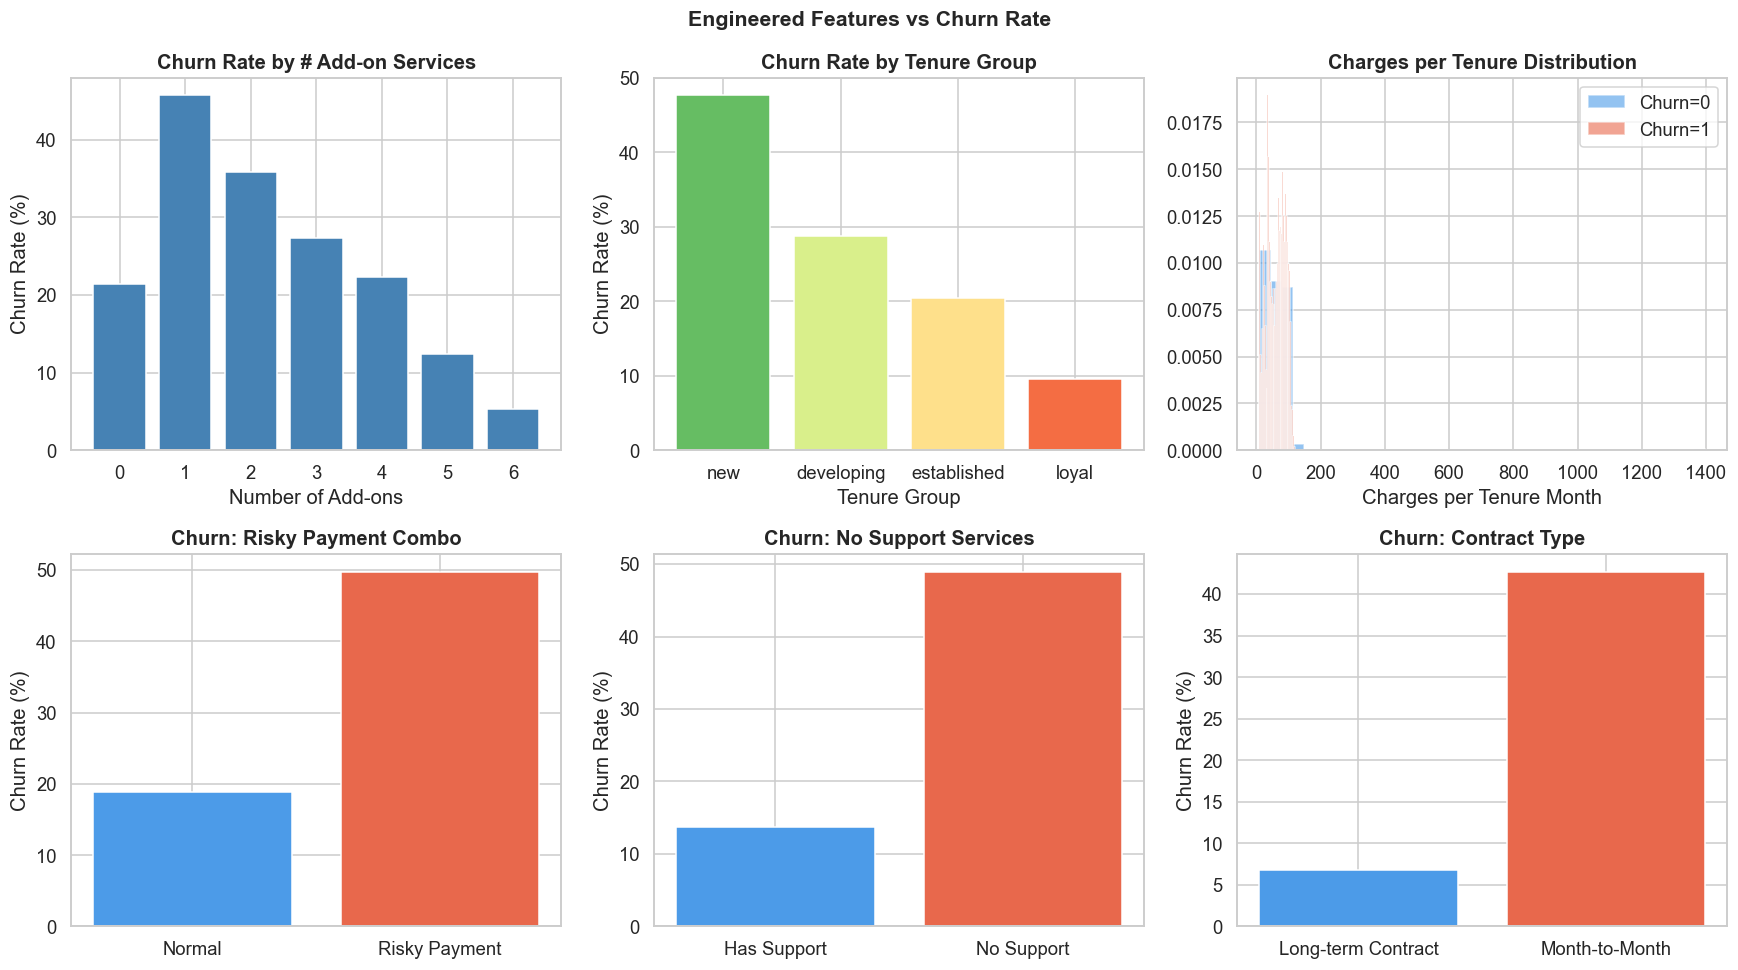

In [5]:
# Visualise new features vs churn
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
colors = ['#4C9BE8', '#E8684C']

# num_addons
addon_churn = df.groupby('num_addons')[TARGET].mean() * 100
axes[0].bar(addon_churn.index, addon_churn.values, color='steelblue', edgecolor='white')
axes[0].set_title('Churn Rate by # Add-on Services', fontweight='bold')
axes[0].set_xlabel('Number of Add-ons')
axes[0].set_ylabel('Churn Rate (%)')

# tenure_group
tg_churn = df.groupby('tenure_group', observed=True)[TARGET].mean() * 100
axes[1].bar(tg_churn.index.astype(str), tg_churn.values,
            color=sns.color_palette('RdYlGn_r', len(tg_churn)), edgecolor='white')
axes[1].set_title('Churn Rate by Tenure Group', fontweight='bold')
axes[1].set_xlabel('Tenure Group')
axes[1].set_ylabel('Churn Rate (%)')

# charges_per_tenure distribution
for churn_val, color in zip([0, 1], colors):
    subset = df[df[TARGET] == churn_val]['charges_per_tenure']
    axes[2].hist(subset, bins=40, alpha=0.6, color=color,
                 label=f'Churn={churn_val}', density=True)
axes[2].set_title('Charges per Tenure Distribution', fontweight='bold')
axes[2].set_xlabel('Charges per Tenure Month')
axes[2].legend()

# risky_payment
rp = df.groupby('risky_payment')[TARGET].mean() * 100
axes[3].bar(['Normal', 'Risky Payment'], rp.values,
            color=['#4C9BE8', '#E8684C'], edgecolor='white')
axes[3].set_title('Churn: Risky Payment Combo', fontweight='bold')
axes[3].set_ylabel('Churn Rate (%)')

# no_support
ns = df.groupby('no_support')[TARGET].mean() * 100
axes[4].bar(['Has Support', 'No Support'], ns.values,
            color=['#4C9BE8', '#E8684C'], edgecolor='white')
axes[4].set_title('Churn: No Support Services', fontweight='bold')
axes[4].set_ylabel('Churn Rate (%)')

# is_monthly
im = df.groupby('is_monthly')[TARGET].mean() * 100
axes[5].bar(['Long-term Contract', 'Month-to-Month'], im.values,
            color=['#4C9BE8', '#E8684C'], edgecolor='white')
axes[5].set_title('Churn: Contract Type', fontweight='bold')
axes[5].set_ylabel('Churn Rate (%)')

plt.suptitle('Engineered Features vs Churn Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Identify Feature Types

In [6]:
# Drop TotalCharges (multicollinear with tenure) now that we have charges_per_tenure
df.drop(columns=['TotalCharges'], inplace=True)

X = df.drop(columns=[TARGET])
y = df[TARGET]

# Identify column types
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Numeric features  ({len(numeric_cols)}): {numeric_cols}')
print(f'Categorical features ({len(categorical_cols)}): {categorical_cols}')
print(f'\nTotal features: {len(numeric_cols) + len(categorical_cols)}')
print(f'Target: {TARGET} | Shape: X={X.shape}, y={y.shape}')

Numeric features  (5): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'charges_per_tenure', 'num_addons']
Categorical features (16): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']

Total features: 21
Target: Churn | Shape: X=(7043, 24), y=(7043,)


---
## 5. Train / Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Train churn rate: {y_train.mean():.2%}')
print(f'Test churn rate:  {y_test.mean():.2%}')

Train: (5634, 24) | Test: (1409, 24)
Train churn rate: 26.54%
Test churn rate:  26.54%


---
## 6. Build sklearn Preprocessing Pipeline

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Numeric: impute median → scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

# Categorical: impute mode → one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols),
])

print('Preprocessor built ✅')
preprocessor

Preprocessor built ✅


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'charges_per_tenure', 'num_addons']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod',
                                  'tenure_group'])])

In [9]:
# Fit & transform training data to inspect output
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)

# Get feature names after one-hot encoding
ohe_features = preprocessor.named_transformers_['cat']['onehot']\
                            .get_feature_names_out(categorical_cols).tolist()
all_feature_names = numeric_cols + ohe_features

print(f'Features after encoding: {len(all_feature_names)}')
print(f'Transformed train shape: {X_train_transformed.shape}')
print(f'Transformed test shape:  {X_test_transformed.shape}')

Features after encoding: 50
Transformed train shape: (5634, 50)
Transformed test shape:  (1409, 50)


In [10]:
# Peek at transformed data
pd.DataFrame(X_train_transformed, columns=all_feature_names).head(3)

,SeniorCitizen,tenure,MonthlyCharges,charges_per_tenure,num_addons,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_developing,tenure_group_established,tenure_group_loyal,tenure_group_new
0,-0.441773,0.102371,-0.521976,-0.236288,0.507935,0.0,1.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,-0.441773,-0.711743,0.337478,0.182960,-0.570530,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,-0.441773,-0.793155,-0.809013,-0.322843,0.507935,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


---
## 7. Handle Class Imbalance with SMOTE

Before SMOTE:
0    4139
1    1495
Name: Churn, dtype: int64
Churn rate: 26.54%

After SMOTE:
0    4139
1    4139
Name: Churn, dtype: int64
Churn rate: 50.00%


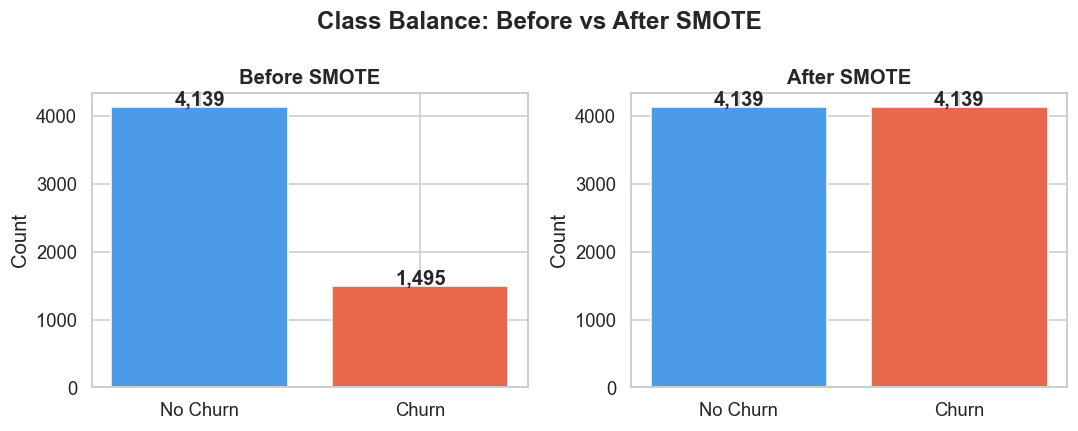

In [11]:
print('Before SMOTE:')
print(y_train.value_counts())
print(f'Churn rate: {y_train.mean():.2%}')

smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_transformed, y_train)

print('\nAfter SMOTE:')
print(pd.Series(y_train_resampled).value_counts())
print(f'Churn rate: {pd.Series(y_train_resampled).mean():.2%}')

# Plot before/after
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, data, title in zip(
    axes,
    [y_train, pd.Series(y_train_resampled)],
    ['Before SMOTE', 'After SMOTE']
):
    counts = data.value_counts()
    ax.bar(['No Churn', 'Churn'], counts.values,
           color=['#4C9BE8', '#E8684C'], edgecolor='white')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 20, f'{v:,}', ha='center', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')

plt.suptitle('Class Balance: Before vs After SMOTE', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Save Processed Data

In [12]:
import os, joblib

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Save train/test splits (original, before SMOTE)
train_df = X_train.copy()
train_df[TARGET] = y_train.values
test_df = X_test.copy()
test_df[TARGET] = y_test.values

train_df.to_csv('../data/processed/train.csv', index=False)
test_df.to_csv('../data/processed/test.csv', index=False)

# Save the fitted preprocessor
joblib.dump(preprocessor, '../models/preprocessor.pkl')

# Save feature names for later use
import json
with open('../models/feature_names.json', 'w') as f:
    json.dump({'numeric': numeric_cols, 'categorical': categorical_cols,
               'all_encoded': all_feature_names}, f, indent=2)

print('✅ Saved:')
print('  data/processed/train.csv')
print('  data/processed/test.csv')
print('  models/preprocessor.pkl')
print('  models/feature_names.json')

✅ Saved:
  data/processed/train.csv
  data/processed/test.csv
  models/preprocessor.pkl
  models/feature_names.json


---
## Summary

In [13]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║             FEATURE ENGINEERING SUMMARY                         ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  NEW FEATURES CREATED (6)                                        ║
║  • charges_per_tenure  — monthly spend efficiency               ║
║  • tenure_group        — new/developing/established/loyal       ║
║  • num_addons          — count of add-on services               ║
║  • risky_payment       — paperless + electronic check combo     ║
║  • no_support          — no security AND no tech support        ║
║  • is_monthly          — month-to-month contract flag           ║
║                                                                  ║
║  DROPPED                                                         ║
║  • TotalCharges (multicollinear with tenure)                    ║
║  • customerID (identifier, not a feature)                       ║
║                                                                  ║
║  PIPELINE                                                        ║
║  • Numeric  → MedianImputer → StandardScaler                    ║
║  • Categoric → ModeImputer → OneHotEncoder                      ║
║                                                                  ║
║  CLASS IMBALANCE                                                 ║
║  • SMOTE applied on training set only (never on test)           ║
║                                                                  ║
║  NEXT STEP → 03_modeling.ipynb                                   ║
║  • Logistic Regression (baseline)                               ║
║  • XGBoost + LightGBM                                           ║
║  • Hyperparameter tuning                                        ║
║  • SHAP explainability                                          ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║             FEATURE ENGINEERING SUMMARY                         ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  NEW FEATURES CREATED (6)                                        ║
║  • charges_per_tenure  — monthly spend efficiency               ║
║  • tenure_group        — new/developing/established/loyal       ║
║  • num_addons          — count of add-on services               ║
║  • risky_payment       — paperless + electronic check combo     ║
║  • no_support          — no security AND no tech support        ║
║  • is_monthly          — month-to-month contract flag           ║
║                                                                  ║
║  DROPPED                                                         ║
║  • TotalCharges (multicollinear with tenure)                    ║
║  • customerID (identifier, not a featur